# StratifiedKFold Validation - Species Distribution per Fold

This notebook verifies that StratifiedKFold is working correctly by visualizing the species distribution in train and validation sets for each fold. 

**StratifiedKFold** ensures each species is proportionally represented in both train and validation sets (unlike GroupKFold which keeps entire groups together).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load and process data (same as in datasets.py)
dataset_path = "datasets"
df = pd.read_csv(os.path.join(dataset_path, "train.csv"))

# Get unique samples (pivot to match dataset processing)
df["base_sample_id"] = df["sample_id"].str.split("__").str[0]
df_unique = df.drop_duplicates(subset=["base_sample_id"])[["base_sample_id", "Species"]].reset_index(drop=True)

print(f"Total unique samples: {len(df_unique)}")
print(f"Unique species: {df_unique['Species'].nunique()}")
print(f"\nSpecies counts:\n{df_unique['Species'].value_counts()}")

Total unique samples: 357
Unique species: 15

Species counts:
Species
Ryegrass_Clover                                                98
Ryegrass                                                       62
Phalaris_Clover                                                42
Clover                                                         41
Fescue                                                         28
Lucerne                                                        22
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed    11
Fescue_CrumbWeed                                               10
WhiteClover                                                    10
Phalaris                                                        8
Phalaris_Ryegrass_Clover                                        8
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass                 7
SubcloverLosa                                                   5
SubcloverDalkeith                                               3
Mixed 

In [7]:
# Apply StratifiedKFold with Species as the stratification column
from sklearn.model_selection import StratifiedKFold

n_folds = 5
groups_col_name = "Species"
seed = 42

stratify_labels = df_unique[groups_col_name].values
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
fold_splits = list(kfold.split(range(len(df_unique)), stratify_labels))

# Collect species distribution for each fold
fold_data = []
for fold_idx, (train_indices, val_indices) in enumerate(fold_splits):
    # Get species for train and val sets
    train_species = df_unique.iloc[train_indices]["Species"].value_counts()
    val_species = df_unique.iloc[val_indices]["Species"].value_counts()
    
    for species in train_species.index:
        fold_data.append({
            "Fold": fold_idx + 1,
            "Species": species,
            "Set": "Train",
            "Count": train_species.get(species, 0)
        })
    
    for species in val_species.index:
        fold_data.append({
            "Fold": fold_idx + 1,
            "Species": species,
            "Set": "Validation",
            "Count": val_species.get(species, 0)
        })

fold_df = pd.DataFrame(fold_data)
print("Species distribution collected for all folds using StratifiedKFold")

Species distribution collected for all folds using StratifiedKFold


d:\Project\Competition\CSIRO-Image2Biomass-Prediction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


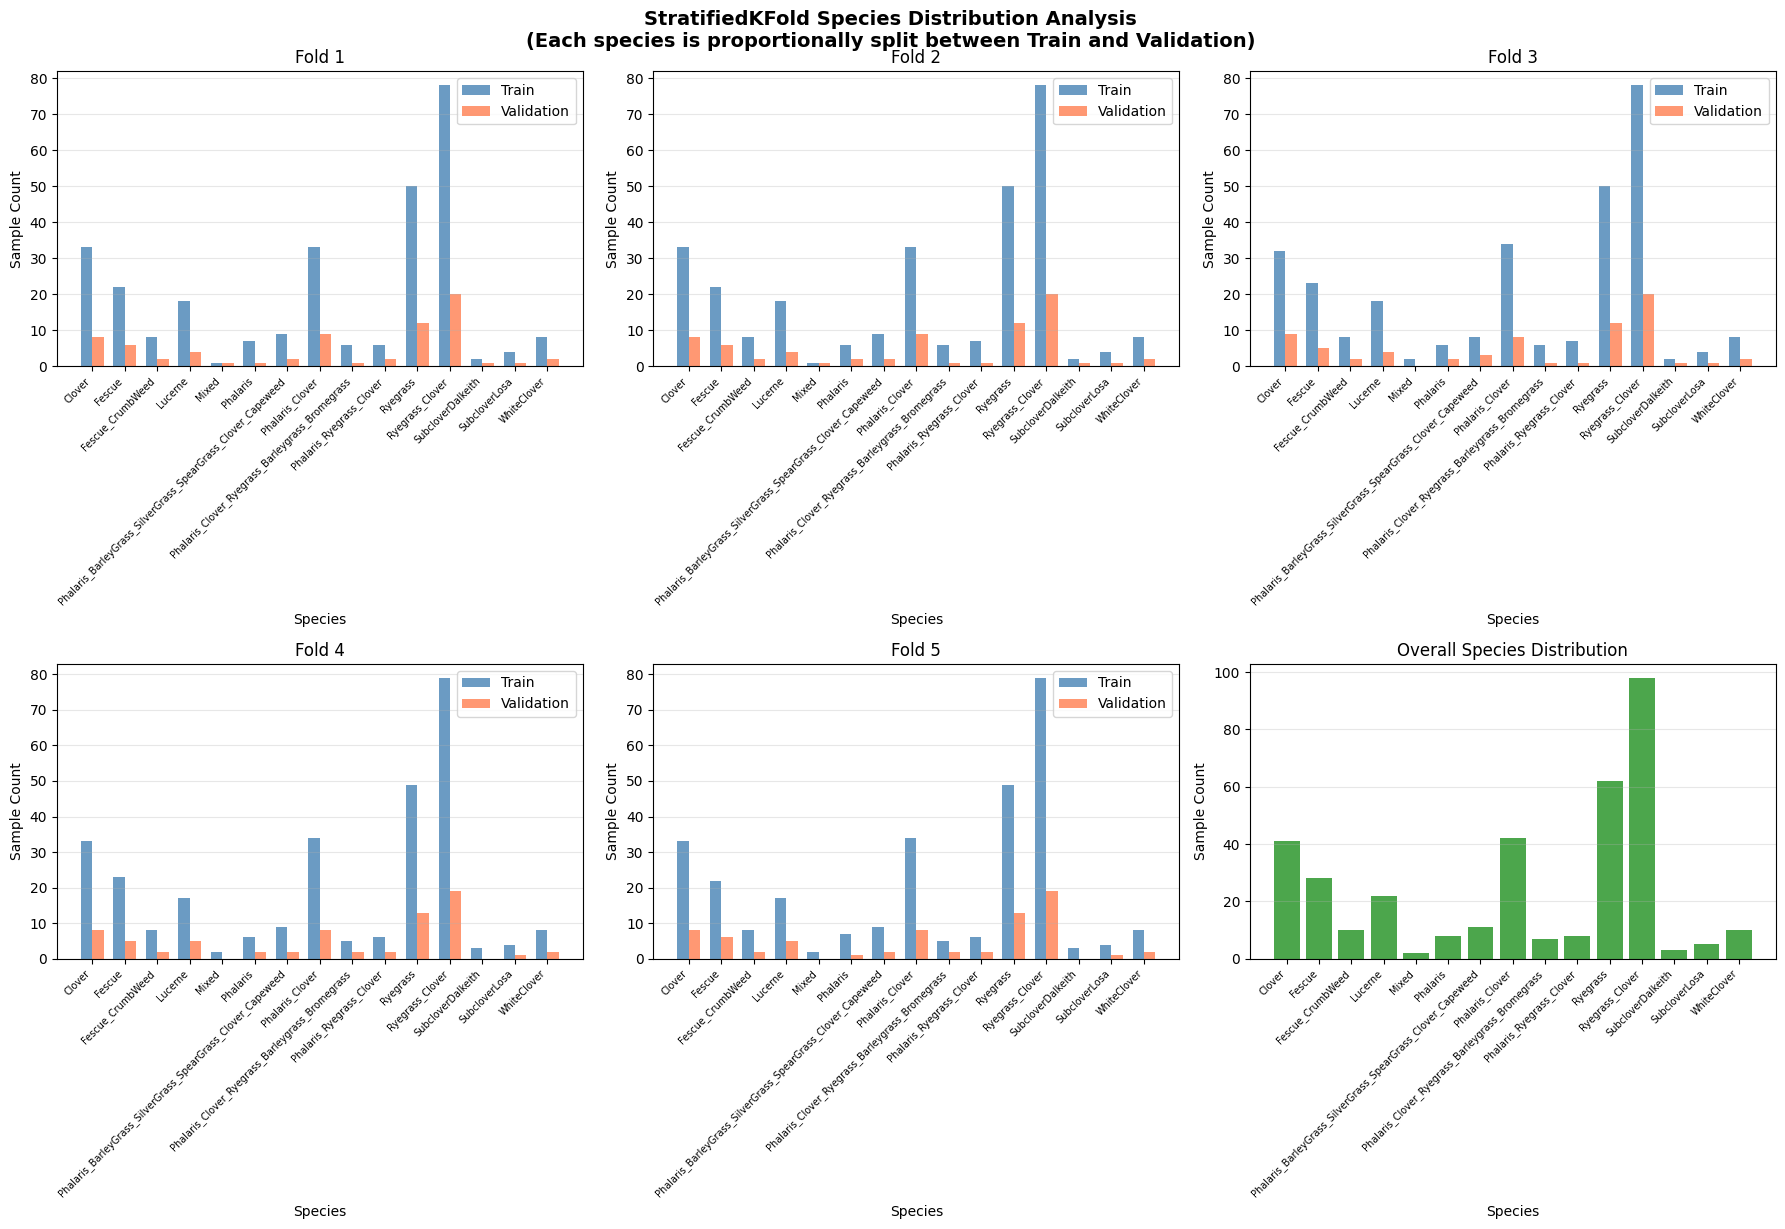

In [8]:
# Create visualization - Species distribution per fold (Stratified)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

all_species = sorted(df_unique["Species"].unique())

for fold_idx in range(n_folds):
    ax = axes[fold_idx]
    fold_train = fold_df[(fold_df["Fold"] == fold_idx + 1) & (fold_df["Set"] == "Train")]
    fold_val = fold_df[(fold_df["Fold"] == fold_idx + 1) & (fold_df["Set"] == "Validation")]
    
    x = np.arange(len(all_species))
    width = 0.35
    
    train_counts = [fold_train[fold_train["Species"] == s]["Count"].values[0] if s in fold_train["Species"].values else 0 for s in all_species]
    val_counts = [fold_val[fold_val["Species"] == s]["Count"].values[0] if s in fold_val["Species"].values else 0 for s in all_species]
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, val_counts, width, label='Validation', color='coral', alpha=0.8)
    
    ax.set_xlabel('Species')
    ax.set_ylabel('Sample Count')
    ax.set_title(f'Fold {fold_idx + 1}')
    ax.set_xticks(x)
    ax.set_xticklabels(all_species, rotation=45, ha='right', fontsize=7)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Use the last subplot for overall distribution
ax = axes[5]
species_counts = df_unique["Species"].value_counts().reindex(all_species)
ax.bar(range(len(species_counts)), species_counts.values, color='green', alpha=0.7)
ax.set_xlabel('Species')
ax.set_ylabel('Sample Count')
ax.set_title('Overall Species Distribution')
ax.set_xticks(range(len(species_counts)))
ax.set_xticklabels(all_species, rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('StratifiedKFold Species Distribution Analysis\n(Each species is proportionally split between Train and Validation)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [9]:
# Verify StratifiedKFold: Check species presence in both train and val
print("=" * 70)
print("STRATIFIEDKFOLD VALIDATION - Species Distribution Analysis")
print("=" * 70)

for fold_idx, (train_indices, val_indices) in enumerate(fold_splits):
    train_species = df_unique.iloc[train_indices]["Species"].value_counts()
    val_species = df_unique.iloc[val_indices]["Species"].value_counts()
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train samples: {len(train_indices)}, Val samples: {len(val_indices)}")
    print(f"  Train/Val ratio: {len(train_indices)/len(val_indices):.2f}")
    
    # Check if all species are in both sets
    all_species_in_train = set(train_species.index)
    all_species_in_val = set(val_species.index)
    missing_in_train = set(all_species) - all_species_in_train
    missing_in_val = set(all_species) - all_species_in_val
    
    if missing_in_val:
        print(f"  ⚠️  Species missing in validation (too few samples): {missing_in_val}")
    else:
        print(f"  ✅ All species present in both train and validation!")

print("\n" + "=" * 70)
print("✅ StratifiedKFold ensures proportional species distribution in each fold!")
print("=" * 70)

STRATIFIEDKFOLD VALIDATION - Species Distribution Analysis

Fold 1:
  Train samples: 285, Val samples: 72
  Train/Val ratio: 3.96
  ✅ All species present in both train and validation!

Fold 2:
  Train samples: 285, Val samples: 72
  Train/Val ratio: 3.96
  ✅ All species present in both train and validation!

Fold 3:
  Train samples: 286, Val samples: 71
  Train/Val ratio: 4.03
  ⚠️  Species missing in validation (too few samples): {'Mixed'}

Fold 4:
  Train samples: 286, Val samples: 71
  Train/Val ratio: 4.03
  ⚠️  Species missing in validation (too few samples): {'Mixed', 'SubcloverDalkeith'}

Fold 5:
  Train samples: 286, Val samples: 71
  Train/Val ratio: 4.03
  ⚠️  Species missing in validation (too few samples): {'Mixed', 'SubcloverDalkeith'}

✅ StratifiedKFold ensures proportional species distribution in each fold!


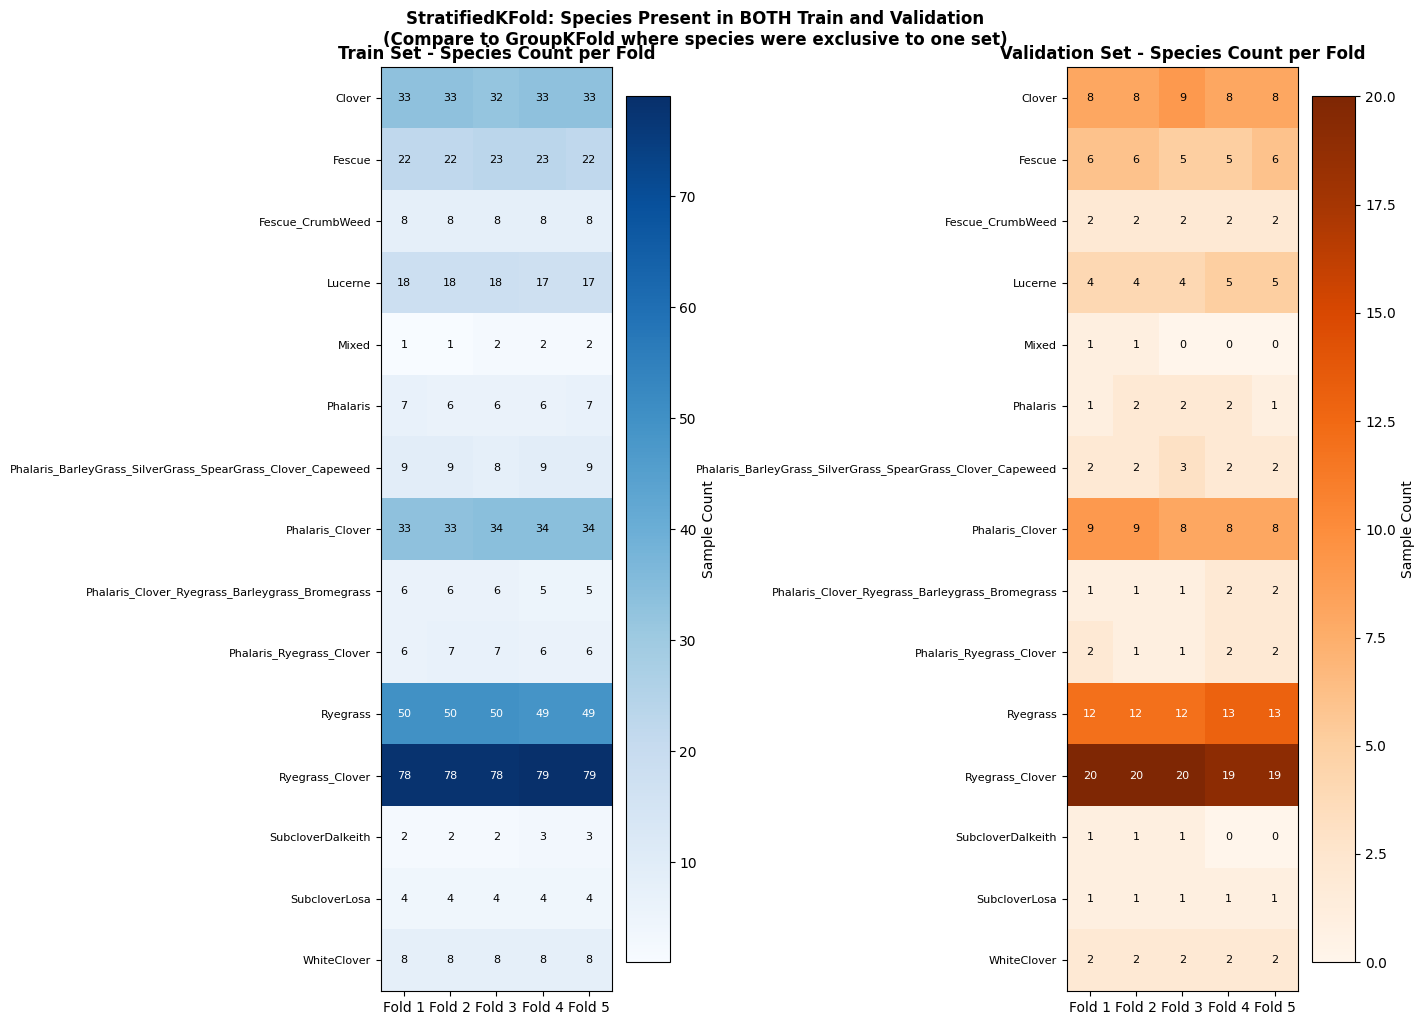

In [10]:
# Create a heatmap comparing train vs val proportions for each species per fold
species_list = sorted(df_unique["Species"].unique())
n_species = len(species_list)

# Create matrices for train and val counts
train_matrix = np.zeros((n_species, n_folds))
val_matrix = np.zeros((n_species, n_folds))

for fold_idx, (train_indices, val_indices) in enumerate(fold_splits):
    train_species = df_unique.iloc[train_indices]["Species"].value_counts()
    val_species = df_unique.iloc[val_indices]["Species"].value_counts()
    
    for i, species in enumerate(species_list):
        train_matrix[i, fold_idx] = train_species.get(species, 0)
        val_matrix[i, fold_idx] = val_species.get(species, 0)

# Create side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

# Train heatmap
im1 = ax1.imshow(train_matrix, aspect='auto', cmap='Blues')
ax1.set_xticks(range(n_folds))
ax1.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax1.set_yticks(range(n_species))
ax1.set_yticklabels(species_list, fontsize=8)
ax1.set_title('Train Set - Species Count per Fold', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Sample Count')

# Add text annotations
for i in range(n_species):
    for j in range(n_folds):
        text = ax1.text(j, i, int(train_matrix[i, j]), ha="center", va="center", 
                        color="white" if train_matrix[i, j] > train_matrix.max()/2 else "black", fontsize=8)

# Val heatmap
im2 = ax2.imshow(val_matrix, aspect='auto', cmap='Oranges')
ax2.set_xticks(range(n_folds))
ax2.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax2.set_yticks(range(n_species))
ax2.set_yticklabels(species_list, fontsize=8)
ax2.set_title('Validation Set - Species Count per Fold', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Sample Count')

# Add text annotations
for i in range(n_species):
    for j in range(n_folds):
        text = ax2.text(j, i, int(val_matrix[i, j]), ha="center", va="center", 
                        color="white" if val_matrix[i, j] > val_matrix.max()/2 else "black", fontsize=8)

plt.tight_layout()
plt.suptitle('StratifiedKFold: Species Present in BOTH Train and Validation\n(Compare to GroupKFold where species were exclusive to one set)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.show()

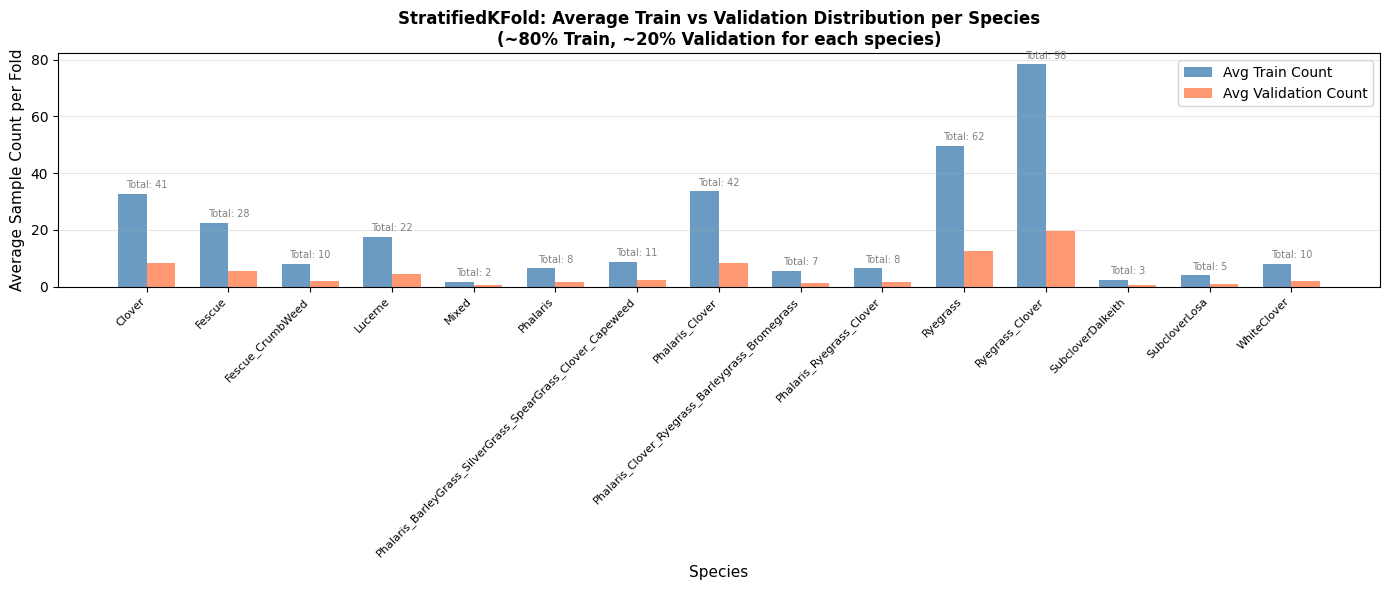


Train/Val Split Ratios per Species:
--------------------------------------------------
Clover                                            : Train 80.0% | Val 20.0%
Fescue                                            : Train 80.0% | Val 20.0%
Fescue_CrumbWeed                                  : Train 80.0% | Val 20.0%
Lucerne                                           : Train 80.0% | Val 20.0%
Mixed                                             : Train 80.0% | Val 20.0%
Phalaris                                          : Train 80.0% | Val 20.0%
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed: Train 80.0% | Val 20.0%
Phalaris_Clover                                   : Train 80.0% | Val 20.0%
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass   : Train 80.0% | Val 20.0%
Phalaris_Ryegrass_Clover                          : Train 80.0% | Val 20.0%
Ryegrass                                          : Train 80.0% | Val 20.0%
Ryegrass_Clover                                   : Train 80.0% | V

In [11]:
# Show the train/val split ratio per species across all folds
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate average train and val counts per species
avg_train = train_matrix.mean(axis=1)
avg_val = val_matrix.mean(axis=1)
total_per_species = df_unique["Species"].value_counts().reindex(species_list).values

x = np.arange(len(species_list))
width = 0.35

bars1 = ax.bar(x - width/2, avg_train, width, label='Avg Train Count', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, avg_val, width, label='Avg Validation Count', color='coral', alpha=0.8)

# Add total count as text above bars
for i, (t, v, total) in enumerate(zip(avg_train, avg_val, total_per_species)):
    ax.annotate(f'Total: {total}', xy=(i, max(t, v) + 2), ha='center', fontsize=7, color='gray')

ax.set_xlabel('Species', fontsize=11)
ax.set_ylabel('Average Sample Count per Fold', fontsize=11)
ax.set_title('StratifiedKFold: Average Train vs Validation Distribution per Species\n(~80% Train, ~20% Validation for each species)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(species_list, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the exact ratios
print("\nTrain/Val Split Ratios per Species:")
print("-" * 50)
for i, species in enumerate(species_list):
    train_pct = avg_train[i] / total_per_species[i] * 100
    val_pct = avg_val[i] / total_per_species[i] * 100
    print(f"{species:50s}: Train {train_pct:.1f}% | Val {val_pct:.1f}%")